# Tutorial: Autoencoder (AE)
> Created Aug. 2024 for the FSU Course: *Machine Learning in Physics* <br>
> H. B. Prosper<br>

## Introduction

The [Sloan Digital Sky Survey](https://sloan.org/programs/research/sloan-digital-sky-survey) (SDSS) exemplifies the longstanding tradition of researchers in astronomy, astrophysics, and cosmology of making data public. The SDSS provides a wealth of astrophysical and astronomical data that have been used for research-level work as well as for educational purposes. The collaborations at the Large Hadron Collider at CERN also release their data, albeit with a longer latency than is typical in astronomy. 

## SDSS Color Data for Stars
SDSS stronomers characterize the color of celestial objects using the fluxes measured through 5 SDSS filters:

| __Filter__        | __Wavelength (nm)__   |
| :---              | :--   |
| Ultraviolet (u)   | 354.3 |
| Green (g)         | 477.0 |
| Red (r)           | 623.1 |
| Near Infrared (i) | 762.5 |
| Infrared (z)      | 913.4 |

In this notebook we use a simple __autoencoder__ to search for structure in the SDSS stellar color data.  Given two spaces $x \in \mathbb{R}^N$ and $z \in \mathbb{R}^n$, where $n \ll N$, an autoencoder models the mappings $h: x \rightarrow z$ followed by $g: z \rightarrow x$. The first mapping is called the __encoder__ and the second mapping is called the __decoder__. The low-dimensional space $\mathbb{R}^n$ is called the __latent space__. 

There is no reason, *a priori*, why an autoencoder should cluster data in the latent space; an autoencoder simply creates a compressed representation of the original data. However, if clusters exist in the original space $\mathbb{R}^N$ one would expect these clusters to be mapped to clusters in the latent space provided that in approximating the identity mapping $h: x \rightarrow z$ and $g: z \rightarrow x$  sufficient information is retained in the latent space. 

The data used in this example have been extracted from the SDSS website

https://cas.sdss.org/dr18/SearchTools/sql

using the following SQL query (see https://www.astroml.org/)

```sql
SELECT TOP 255000
  p.ra, p.dec, s.z as redshift, p.u, p.g, p.r, p.i, p.z
FROM PhotoObj AS p
  JOIN SpecObj AS s ON s.bestobjid = p.objid
WHERE 
      p.u BETWEEN 0 AND 30
  AND p.g BETWEEN 0 AND 30
  AND p.r BETWEEN 0 AND 30
  AND p.i BETWEEN 0 AND 30
  AND p.z BETWEEN 0 AND 30
  AND s.class = 'STAR'
``` 

**Notes**

 1. This notebook uses the `corner` module:
    ```bash
    conda install corner -c conda-forge
    ```

## Running on Google Colab
If on Google Colab (https://colab.research.google.com), execute cell below.

In [1]:
try:
    import google.colab

    REPO = 'hbprosper/mlinphysics'
    
    url = f"https://raw.githubusercontent.com/{REPO}/refs/heads/main"
    !wget -q {url}/clone2colab.ipynb -O clone2colab.ipynb
    %run clone2colab.ipynb
    
    IN_COLAB = True
    
except ImportError:
    
    IN_COLAB = False

In [2]:
# standard system modules
import os, sys

# standard module for tabular data
import pandas as pd

# standard module for array manipulation
import numpy as np

# to reimport Python modules
import importlib

# standard module for high-quality plots
import matplotlib as mp
import matplotlib.pyplot as plt

# standard research-level machine learning toolkit from Meta (FKA: FaceBook)
import torch
import torch.nn as nn
import torch.nn.functional as F

# module to reimport Python modules
import importlib

# module for shell utilities
import shutil

# ML in physics module
import mlinphysics.nn as mlp
import mlinphysics.utils.data as dat
import mlinphysics.utils.monitor as mon

from tqdm import tqdm

# update fonts

plt.rcParams.update({
  "text.usetex": shutil.which('latex') is not None,
  "font.family": "sans-serif",
  "font.sans-serif": "Helvetica",
  "font.size": 14
})

## Computational Device

In [3]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\n\tAvailable device: {str(DEVICE):4s}\n')


	Available device: cpu 



## Load Star Color Data

In [4]:
importlib.reload(dat)

datafile = '../data/sdss_stars.csv.gz'

if dat.download(datafile):

    df = pd.read_csv(datafile, comment="#")
    
    print(len(df))
else:
    raise RuntimeError(f'''
    Download of file {datafile} failed.
    ''')

df[:10]

255000


,ra,dec,redshift,u,g,r,i,z
0,38.051960,-1.036208,-0.000061,24.63467,21.49866,21.45066,19.92876,21.05994
1,47.821800,1.046891,0.000061,19.84112,18.31459,17.70017,17.45584,17.36307
2,55.307333,0.962797,0.000064,23.39600,20.05284,18.66665,18.02476,17.65357
3,55.826906,0.929775,-0.000060,23.44068,20.98102,19.55524,19.04727,18.76338
4,55.926503,0.914214,0.000062,23.00440,20.71241,19.46002,18.99217,18.64949
5,55.943001,0.972382,-0.000061,23.29870,21.16563,19.70608,18.86826,18.36315
6,56.326120,0.941452,-0.000060,21.25649,18.50552,17.13887,16.55940,16.24788
7,94.267523,0.058515,0.000064,18.22665,16.83175,16.25636,15.98967,15.81954
8,94.582571,0.983114,0.000063,19.82014,18.11700,17.57555,17.22457,17.13254
9,83.476756,-0.891474,0.000064,21.23520,18.71469,17.34940,15.82016,14.98959


## Plot Color Data

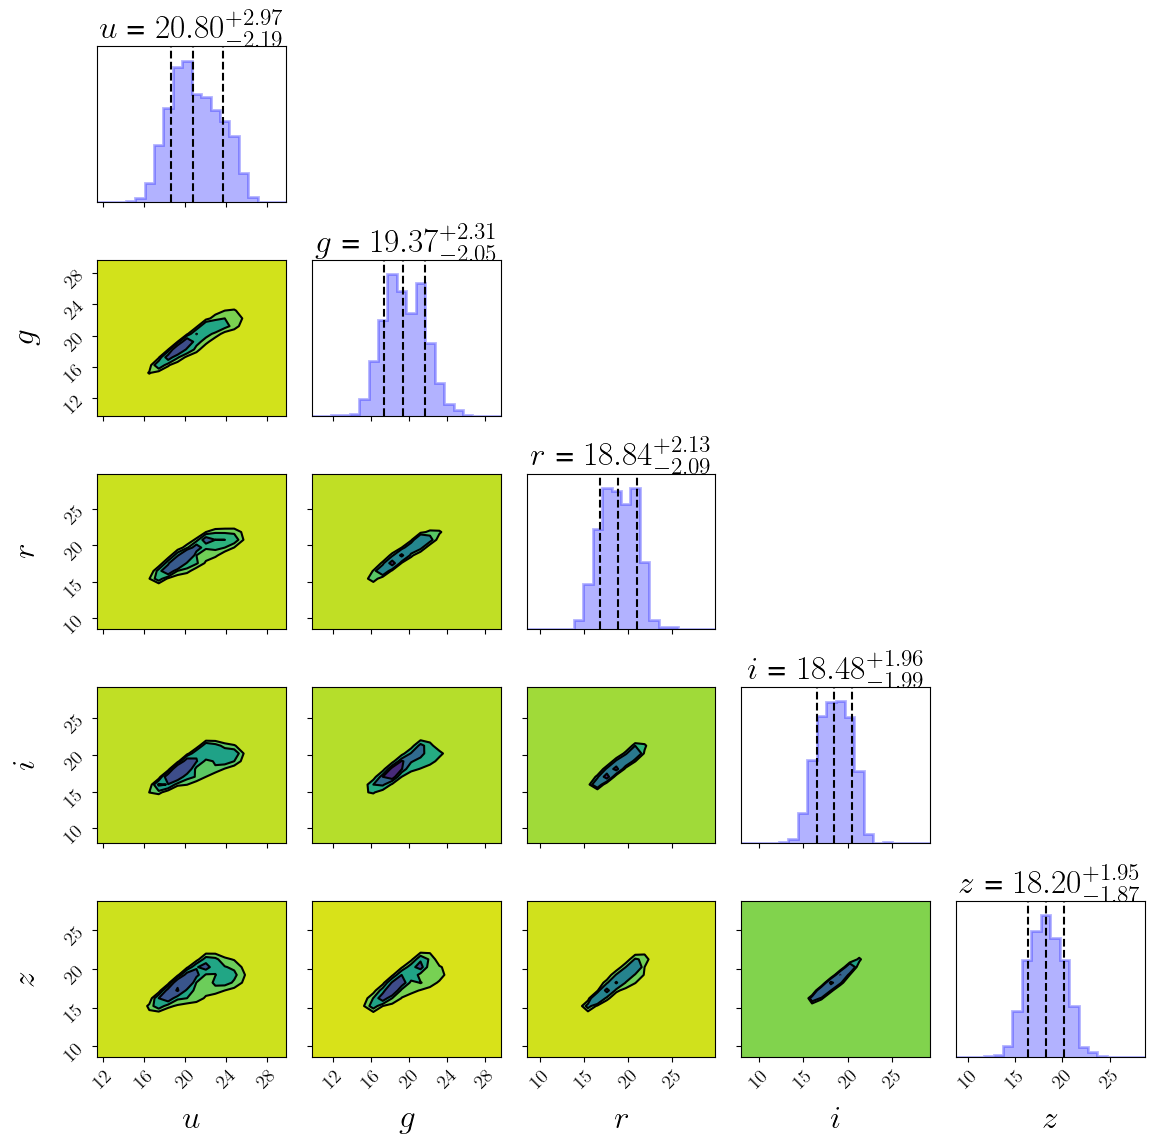

In [18]:
def plot_colors(data,
                xmin=-0.5, xmax=0.5, 
                ymin=-0.5, ymax=0.5,
                ftsize=14):
    import corner
    
    fig = corner.corner(
        data,
        labels=[
        r"$u$",
        r"$g$",
        r"$r$",
        r"$i$", 
        r"$z$"
    ],
    figsize=(5, 5),
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 24},
    label_kwargs={"fontsize": 24},
    hist_kwargs={"color": "blue", 
                 "linewidth": 2,
                 "fill": True,
                 "alpha": 0.3,
                 "facecolor": "blue"},
    fill_contours=True,
    contourf_kwargs={"cmap": "viridis_r", 
                     "colors": None}, 
    );

    fig.tight_layout()
    
    plt.savefig('sdss_colors.png')
    
    plt.show()

# -- Plot
cols = ['u', 'g', 'r', 'i', 'z']
data = df[cols].to_numpy().astype(np.float32)
plot_colors(data);

## Configuration

In [19]:
# name of model
name = 'AE'

# choose whether to create or load a configuration file
load_existing_config = False

if load_existing_config:
    config = mlp.Config(f'{name}.yaml')
else:
    # create new configuration
    config = mlp.Config(name, dirname=name)

    train_size = 150_000
    batch_size = 128
    n_epochs   = 1000

    # number of steps with a fixed learning rate
    n_steps  = 4

    # number of iterations
    n_iterations = n_epochs * int(np.ceil(train_size / batch_size))

    # number of iterations per step
    n_iters_per_step =  int(n_iterations / n_steps)
    
    # training configuration
    # -----------------------------------------
    config('train_size', train_size) # training sample size
    config('batch_size', batch_size) 
    config('n_epochs',   n_epochs)
    config('test_size',  100_000)    # test sample size
    config('val_size',     5_000)    # validation sample size

    config('monitor_step',   100)    # monitor training every n (=10) iterations
    config('delete', True)           # delete losses file before training, if True
    config('frac', 0.015)            # save model if average loss decreases by more
                                     # than frac percent

    # optimizer / scheduler configuration
    # -----------------------------------------
    # a step comprises a given number of iterations
    config('n_steps', n_steps)       # number of training steps
    config('n_iters_per_step', n_iters_per_step)
    config('n_iterations', n_iterations)
    config('base_lr', 2.e-3)         # initial learning rate
    config('gamma', 0.8)             # learning rate scale factor
    
    print(f'\nSave configuration to file {config.cfg_filename}\n')
    config.save()

print(config)


Save configuration to file runs/AE/AE_config.yaml

name: AE
file:
  losses: runs/AE/AE_losses.csv
  params: runs/AE/AE_params.pth
  init_params: runs/AE/AE_init_params.pth
  plots: runs/AE/AE_plots.png
train_size: 150000
batch_size: 128
n_epochs: 1000
test_size: 100000
val_size: 5000
monitor_step: 100
delete: true
frac: 0.015
n_steps: 4
n_iters_per_step: 293000
n_iterations: 1172000
base_lr: 0.002
gamma: 0.8



## Prepare Datasets and DataLoaders
  1. Scale data.
  3. Split data into training, testing, and validation sets.

### Datasets

In [20]:
importlib.reload(dat)

train_size = config('train_size')
val_size   = config('val_size')
test_size  = config('test_size')

# scale data
config('scale', 20)
scaled_data = data / config('scale')

# training dataset (this defines the empirical risk to be minimized)
print('training data')
train_data = dat.Dataset(scaled_data,
                         start=0,
                         end=train_size)

# a random subset of the training data to check for overtraining
# by comparing with the empirical risk from the validation set
print('training data for validation')
train_data_val = dat.Dataset(scaled_data,
                             start=0,
                             end=train_size,
                             random_sample_size=val_size)

# validation dataset (for monitoring training)
print('validation data')
val_data = dat.Dataset(scaled_data,
                       start=train_size,
                       end=train_size + val_size)

# test dataset
print('test data')
test_data= dat.Dataset(scaled_data,
                       start=train_size + val_size,
                       end=train_size + val_size + test_size)

training data
Dataset
  shape of x: torch.Size([150000, 5])

training data for validation
Dataset
  shape of x: torch.Size([5000, 5])

validation data
Dataset
  shape of x: torch.Size([5000, 5])

test data
Dataset
  shape of x: torch.Size([100000, 5])



### DataLoaders

In [21]:
import torch.utils.data as td

print('train data loader')
train_loader = td.DataLoader(train_data, batch_size=config('batch_size'))
print('iterations / epoch:', len(train_loader))
print()

print('train data loader for validation')
train_loader_val = td.DataLoader(train_data_val, batch_size=len(train_data_val))

print('validation data loader')
val_loader = td.DataLoader(val_data, batch_size=len(val_data))

print('test data loader')
test_loader = td.DataLoader(test_data, batch_size=len(test_data))

train data loader
iterations / epoch: 1172

train data loader for validation
validation data loader
test data loader


## Build Model

In [22]:
class AutoEncoder(mlp.Model):
    
    def __init__(self, n_width=24):
        # call constructor of base (or super, or parent) class
        super(AutoEncoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(      5, n_width), mlp.Sin(), #nn.LayerNorm(n_width),
            nn.Linear(n_width, n_width), mlp.Sin(), #nn.LayerNorm(n_width),
            nn.Linear(n_width, n_width), mlp.Sin(), #nn.LayerNorm(n_width), 
            nn.Linear(n_width, n_width), mlp.Sin(), #nn.LayerNorm(n_width),
            nn.Linear(n_width, 2), 
                )
        self.decoder = nn.Sequential(
            nn.Linear(      2, n_width), mlp.Sin(), #nn.LayerNorm(n_width),
            nn.Linear(n_width, n_width), mlp.Sin(), #nn.LayerNorm(n_width),
            nn.Linear(n_width, n_width), mlp.Sin(), #nn.LayerNorm(n_width), 
            nn.Linear(n_width, n_width), mlp.Sin(), #nn.LayerNorm(n_width),
            nn.Linear(n_width, 5), 
                )
        
    def forward(self, x):
        y = self.encoder(x)
        y = self.decoder(y)
        return y

## Instantiate Training Objects
  1. `model`
  2. `optimizer`
  1. `scheduler`
  2. `monitor`
  1. `objective`

In [23]:
importlib.reload(mlp)

model = AutoEncoder().to(DEVICE)
print('number of parameters:', mlp.number_of_parameters(model))
print(model)
print()

optimizer = torch.optim.Adam(model.parameters(), lr=config('base_lr'))

# Instantiate learning rate step scheduler
scheduler = mlp.LRStepScheduler(
    optimizer,  
    n_steps=config('n_steps'), 
    n_iters_per_step=config('n_iters_per_step'), 
    base_lr=config('base_lr'), 
    gamma=config('gamma')
)

# Instantiate object that saves average losses to
# a csv file for realtime monitoring
monitor = mon.Monitor(
    config('n_iterations'),
    config('file/losses'),
    monitorstep=config('monitor_step'),
    newlossfile=True,
    frac=config('frac'),
    model=model,
    paramsfile=config('file/params'))

objective = mlp.Objective(model, nn.MSELoss())

number of parameters: 3991
AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=5, out_features=24, bias=True)
    (1): Sin()
    (2): Linear(in_features=24, out_features=24, bias=True)
    (3): Sin()
    (4): Linear(in_features=24, out_features=24, bias=True)
    (5): Sin()
    (6): Linear(in_features=24, out_features=24, bias=True)
    (7): Sin()
    (8): Linear(in_features=24, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=24, bias=True)
    (1): Sin()
    (2): Linear(in_features=24, out_features=24, bias=True)
    (3): Sin()
    (4): Linear(in_features=24, out_features=24, bias=True)
    (5): Sin()
    (6): Linear(in_features=24, out_features=24, bias=True)
    (7): Sin()
    (8): Linear(in_features=24, out_features=5, bias=True)
  )
)

number of milestones:          3

Step | Milestone | LR
-----------------------------
   0 |         0 | 2.0e-03   
-----------------------------
   1 |    293000 | 1.6e-03   
   2 | 

## Define Trainer

In [26]:
importlib.reload(mlp)

def train(objective, optimizer, scheduler, monitor,
          train_loader, train_small_loader, val_loader, n_epochs):
   
    monitor.start()

    for epoch in range(n_epochs):
        
        for X in train_loader:
            
            # set mode to training so that training-specific
            # operations such as dropout, etc., are enabled.
            objective.train()
    
            # clear all gradients
            optimizer.zero_grad()
    
            R = objective(X, X)
    
            # compute gradients
            R.backward()
    
            # take one step downhill in the empirical risk landscape
            optimizer.step()
    
            # check whether to update learning rate
            scheduler.step()
    
            if monitor.step():
    
                # compute average losses on training and validation data
                with torch.no_grad():
                    
                    # set mode to evaluation so that training-specific
                    # operations such as dropout, etc., are disabled.
                    objective.eval()
    
                    # compute average losses on training and validation data
                    x = next(iter(train_small_loader))
                    t_loss = objective(x, x).item()
                
                    x = next(iter(val_loader))
                    v_loss = objective(x, x).item()
               
                # return current learning rate
                lr = scheduler.lr()
    
                # update loss file
                monitor(t_loss, v_loss, lr, epoch)
                    
    monitor.reset()

## Train Model

In [ ]:
TRAIN = True

if TRAIN:
    
    train(
        objective, optimizer, scheduler, monitor,
        train_loader, train_loader_val, val_loader, 
        config('n_epochs'))

monlosses runs/AE/AE_losses.csv

		learning rate:  2.000e-03
     11200|  0.96%|00:00:52|01:29:54| 215.2 it/s|2.800e-04|2.292e-04|         9|

## Apply  Model to Test Data

In [14]:
def normalize_latent_space(z):
    # normalize latent space
    z1, z2 = z.transpose(0, 1)

    norm1 = nn.LayerNorm(z1.shape).to(DEVICE)
    z1 = norm1(z1).detach().cpu().numpy()

    norm2 = nn.LayerNorm(z2.shape).to(DEVICE)
    z2 = norm2(z2).detach().cpu().numpy()
    return z1, z2

In [15]:
def plot_latent(z1, z2, 
                xmin=-3.0, xmax=3.0, ymin=-3.0, ymax=3.0, 
                size=0.04,
                filename='latent_space_01.png'):
    
    # create an empty figure
    fig = plt.figure(figsize=(5, 5))
    
    # add a subplot to it
    nrows, ncols, index = 1,1,1
    ax  = fig.add_subplot(nrows,ncols,index)

    ax.set_title('Latent Space', fontsize=16)

    # axis limits
    ax.set_xlim((xmin, xmax))
    ax.set_xlabel('$z_1$', fontsize=14)

    ax.set_ylim((ymin, ymax))
    ax.set_ylabel('$z_2$', fontsize=14)

    # ax.hist2d(z1, z2, bins=(25, 25), 
    #           range=((xmin, xmax), (ymin, ymax)), cmap='viridis_r')
    
    # plot data in latent space
    ax.scatter(z1, z2, color='blue', s=size)

    fig.tight_layout()
    
    plt.savefig(filename)
    
    plt.show()

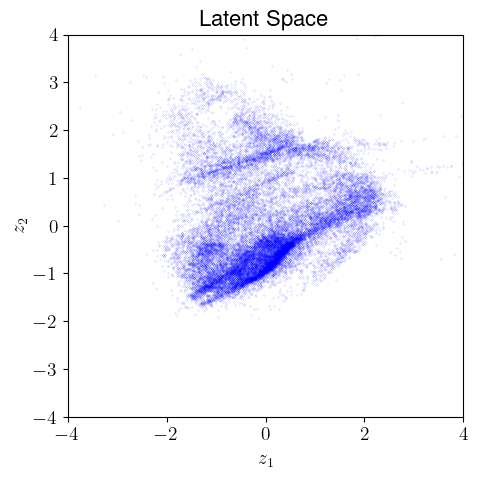

In [16]:
model.load(config('file/params'))
X = next(iter(test_loader))[:25000]
z = model.encoder(X)

z1, z2 = normalize_latent_space(z)

plot_latent(z1, z2, 
            xmin=-4.0, xmax=4.0, ymin=-4.0, ymax=4.0, size=0.005,
            filename='latent_space01.png')

In [17]:
def plot_reconstruction(x, y, 
                xmin=0.7, xmax=1.3, ymin=0.7, ymax=1.3, 
                filename='io_space.png'):

    x, y = x.flatten(), y.flatten()
    
    # create an empty figure
    fig = plt.figure(figsize=(8, 4))
    
    # add a subplot to it
    nrows, ncols = 1, 2
    ax1  = fig.add_subplot(nrows,ncols, 1)
    ax2  = fig.add_subplot(nrows,ncols, 2)

    ax = ax1
    
    # axis limits
    ax.set_xlim((xmin, xmax))
    ax.set_xlabel('$x$', fontsize=14)
    nx = int(10*(xmax-xmin)+1)
    xmarks = np.linspace(xmin, xmax, nx)
    ax.set_xticks(xmarks)
    
    ax.set_ylim((ymin, ymax))
    ax.set_ylabel('$x_{pred}$', fontsize=14)
    ny = int(10*(ymax-ymin)+1)
    ymarks = np.linspace(ymin, ymax, ny)
    ax.set_yticks(ymarks)

    # plot data in latent space
    ax.scatter(x, y, color='blue', s=0.01)

    ax.plot([xmin, xmax], [ymin, ymax], 
            color='yellow', linewidth=2, linestyle='dashed')
    
    ax.grid()

    ax = ax2
    
    # axis limits
    z = (x - y) / y
    zmean = z.mean()
    zstd  = z.std()
    
    xmin, xmax = -0.2, 0.2
    ax.set_xlim((xmin, xmax))
    ax.set_xlabel('$(x_{pred} - x) / x$', fontsize=14)
    nx = 5*int((xmax-xmin)+1)
    xmarks = np.linspace(xmin, xmax, nx)
    ax.set_xticks(xmarks)
    
    #ax.set_ylim((ymin, ymax))

    # plot data in latent space
    ax.hist(z, bins=100, 
            range=(xmin, xmax), 
            color='blue',
            density=True,
            alpha=0.4)
    ax.text(0.02, 80, f'mean: {zmean:8.3f}')
    ax.text(0.02, 70, f'std:  {zstd:8.3f}')
    
    fig.tight_layout()
    
    plt.savefig(filename)
    
    plt.show()

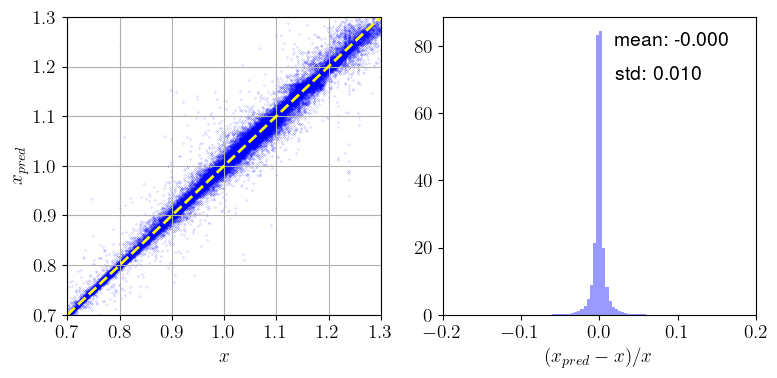

In [18]:
K = 50000
x = X[:K]
pred_x = model(x)

x = x.detach().cpu().numpy().flatten()
y = pred_x.detach().cpu().numpy().flatten()

plot_reconstruction(x, y, 
                    xmin=0.7, xmax=1.3, 
                    ymin=0.7, ymax=1.3)